# 04 · INT8 量化

> FlashAttention 减少中间矩阵的读写。量化则降低参数和激活的存储位宽。本节从量化公式出发，测量注意力输出的误差，比较 INT8 线性层与 FP32 的性能。

**目录**
1. [量化基础](#1-量化基础)
2. [注意力中的量化目标](#2-注意力中的量化目标)
3. [量化粒度与校准](#3-量化粒度与校准)
4. [PyTorch 的 CPU 动态量化](#4-pytorch-的-cpu-动态量化)
5. [量化误差分析](#5-量化误差分析)
6. [量化感知怎么训练](#6-量化感知怎么训练)
7. [基准测试](#7-基准测试)
8. [小结](#8-小结)

这里沿用 $S=QK^\top/\sqrt{d_k}$、$A=\operatorname{softmax}(S)$、$O=AV$。输入 $Q,K,V$ 的形状均为 $(B,h,N,d_k)$，不使用 dropout，有普通和因果自注意力。

INT8 量化不是 2022 FlashAttention 论文的方法或实验，而是本项目额外做的学习拓展。这里用合成输入和随机初始化的层，观察数值误差与运行时间，不评价训练好模型的任务表现。

实验分为两部分：先将张量量化再反量化，用 FP32 运算观察误差；再用 PyTorch 的 CPU 动态量化运行真实 INT8 投影层。前一部分是数值模拟，后一部分的注意力核心仍用浮点 SDPA。两者都不能代表完整的 INT8 FlashAttention kernel。

In [1]:
import platform
import sys
from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
print(f"运行系统: {platform.system()} {platform.release()}")
print(f"Python: {sys.version.split()[0]}")

import math
import json
import copy
import warnings
from dataclasses import dataclass
from pathlib import Path
from contextlib import contextmanager

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.benchmark as benchmark
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = ["DejaVu Sans", "sans-serif"]
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

print(f"PyTorch: {torch.__version__}")
print(f"实验设备: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

try:
    from torch.nn.attention import SDPBackend, sdpa_kernel
except ImportError:
    SDPBackend = None

@contextmanager
def math_backend():
    if SDPBackend is not None:
        with sdpa_kernel(SDPBackend.MATH):
            yield
    else:
        import inspect
        options = dict(enable_flash=False, enable_math=True, enable_mem_efficient=False)
        if "enable_cudnn" in inspect.signature(torch.backends.cuda.sdp_kernel).parameters:
            options["enable_cudnn"] = False
        with torch.backends.cuda.sdp_kernel(**options):
            yield

def save_json(name, value):
    (results_dir / name).write_text(
        json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8"
    )

@torch.no_grad()
def error_metrics(output, reference):
    # 使用 FP64 统计，避免指标本身的 FP32 舍入影响小误差。
    if output.shape != reference.shape or output.numel() == 0:
        raise ValueError("输出与参考必须具有相同的非空形状")
    output, reference = output.double().flatten(), reference.double().flatten()
    diff = output - reference
    ref_norm, out_norm = reference.norm(), output.norm()
    cosine = ((output @ reference) / (out_norm * ref_norm)).item() if (
        ref_norm > 0 and out_norm > 0
    ) else None
    return dict(mse=diff.square().mean().item(),
                relative_l2=(diff.norm() / ref_norm).item() if ref_norm > 0 else None,
                cosine_similarity=cosine, max_abs_error=diff.abs().max().item())

error_records = []
tool_records = []

运行系统: Linux 6.6.87.2-microsoft-standard-WSL2
Python: 3.10.12


PyTorch: 2.11.0+cu128
实验设备: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1 量化基础

### 1.1 scale 与 zero-point

设 $x$ 是浮点数，$s>0$ 是步长（scale），$z$ 是整数零点（zero-point），$q$ 是整数编码：

$$
q=\operatorname{clip}\!\left(\operatorname{round}(x/s)+z,\ q_{\min},q_{\max}\right),
\qquad \hat{x}=s(q-z).
$$

$\hat{x}$ 是反量化后的近似值。步长越小，相邻编码越密；范围之外的值则会被截断。如果没有截断，最近舍入的误差最多约为 $s/2$。

**对称量化**令 $z=0$。本节的 INT8 示例使用 $[-127,127]$，取
$s=\max|x|/127$，留出 `-128` 不用。其他实现也可能使用完整的有符号范围。

**非对称量化**允许 $z\ne0$。以 UINT8 的 $[0,255]$ 为例，先让观测范围包含 0：

$$
x_{\min}'=\min(x_{\min},0),\quad x_{\max}'=\max(x_{\max},0),\quad
s=\frac{x_{\max}'-x_{\min}'}{255},\quad
z=\operatorname{clip}\!\left(\operatorname{round}(-x_{\min}'/s),0,255\right).
$$

这样可以表示真实的 0，适合非负或明显偏移的分布。全零张量单独取 $s=1$，避免除零。零点也经过舍入，因此范围端点可能有一个舍入步长以内的偏差。

### 1.2 用代码实现

下面的量化参数保留可广播的维度；`reduce_dims` 指定哪些维度共享同一组参数。编码实际使用 `int8` 或 `uint8`，反量化结果为 FP32。这些辅助函数只用于前向数值实验，不用于训练。

量化公式及边界输入检查通过


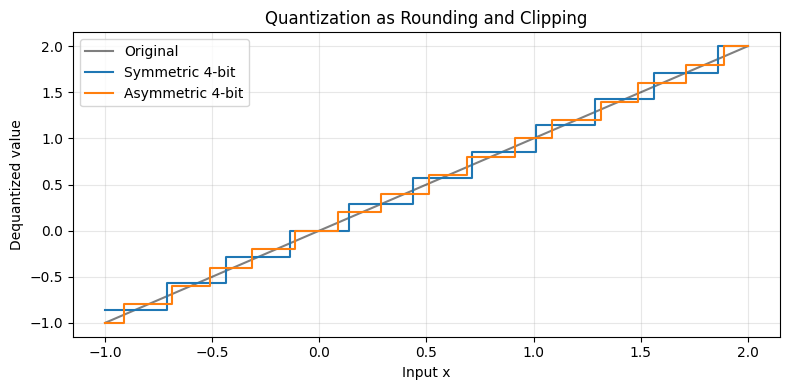

In [2]:
@dataclass
class QParams:
    scale: torch.Tensor
    zero_point: torch.Tensor
    qmin: int
    qmax: int
    bits: int
    symmetric: bool

@dataclass
class QuantizedTensor:
    codes: torch.Tensor
    params: QParams

    def dequantize(self):
        return (self.codes.float() - self.params.zero_point) * self.params.scale

    def storage_bytes(self):
        # 张量数据量，包含参数；不包含 Python 对象、分配器和对齐开销。
        tensors = (self.codes, self.params.scale, self.params.zero_point)
        return sum(t.numel() * t.element_size() for t in tensors)

@torch.no_grad()
def calibrate_qparams(x, bits=8, symmetric=True, reduce_dims=None):
    if not isinstance(bits, int) or not 2 <= bits <= 8:
        raise ValueError("bits 必须是 2 到 8 的整数")
    if not x.is_floating_point() or x.numel() == 0 or not torch.isfinite(x).all():
        raise ValueError("校准输入必须是非空、有限的浮点张量")
    work = x.float()
    dims = tuple(range(work.ndim)) if reduce_dims is None else tuple(reduce_dims)
    if symmetric:
        qmax = 2 ** (bits - 1) - 1
        bound = work.abs().amax(dim=dims, keepdim=True)
        scale = torch.where(bound > 0, bound / qmax, torch.ones_like(bound))
        zero_point = torch.zeros_like(scale, dtype=torch.int32)
        return QParams(scale, zero_point, -qmax, qmax, bits, True)
    qmin, qmax = 0, 2 ** bits - 1
    xmin = work.amin(dim=dims, keepdim=True).clamp(max=0)
    xmax = work.amax(dim=dims, keepdim=True).clamp(min=0)
    span = xmax - xmin
    scale = torch.where(span > 0, span / qmax, torch.ones_like(span))
    zero_point = torch.round(-xmin / scale).clamp(qmin, qmax).to(torch.int32)
    return QParams(scale, zero_point, qmin, qmax, bits, False)

@torch.no_grad()
def quantize_tensor(x, params):
    codes = (torch.round(x.float() / params.scale) + params.zero_point).clamp(
        params.qmin, params.qmax
    )
    dtype = torch.int8 if params.symmetric else torch.uint8
    return QuantizedTensor(codes.to(dtype), params)

def quantize_dequantize(x, bits=8, symmetric=True, reduce_dims=None):
    params = calibrate_qparams(x, bits, symmetric, reduce_dims)
    return quantize_tensor(x, params).dequantize()

# 验证全零、常量、非负及混合符号输入。
examples = [torch.zeros(9), torch.full((9,), 3.0), torch.full((9,), -3.0),
            torch.linspace(0, 3, 31), torch.linspace(-2, 3, 31)]
for x in examples:
    for symmetric in (True, False):
        params = calibrate_qparams(x, symmetric=symmetric)
        packed = quantize_tensor(x, params)
        torch.testing.assert_close(packed.dequantize(), x, rtol=0,
                                   atol=params.scale.max().item() / 2 + 1e-6)
        assert params.scale.min() > 0
        assert torch.isfinite(packed.dequantize()).all()
print("量化公式及边界输入检查通过")

x_vis = torch.linspace(-1, 2, 121)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_vis.numpy(), x_vis.numpy(), color="black", alpha=0.5, label="Original")
for symmetric in (True, False):
    y = quantize_dequantize(x_vis, bits=4, symmetric=symmetric)
    ax.step(x_vis.numpy(), y.numpy(), where="mid",
            label="Symmetric 4-bit" if symmetric else "Asymmetric 4-bit")
ax.set(xlabel="Input x", ylabel="Dequantized value", title="Quantization as Rounding and Clipping")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "04_quantization_basics.png", dpi=120, bbox_inches="tight")
plt.show()

### 1.3 INT8 与 FP8

| 格式 | 数值表示 | 本节的用法 |
|------|----------|------------|
| INT8 / UINT8 | 整数编码，通过 $s,z$ 映射到实数 | 实现公式，并运行 CPU INT8 投影层 |
| FP8 E4M3 | 1 位符号、4 位指数、3 位尾数 | 介绍格式，不测 FP8 kernel |
| FP8 E5M2 | 1 位符号、5 位指数、2 位尾数 | 比 E4M3 有更大动态范围，尾数精度更低 |

FP8 的指数允许数值跨越多个数量级，但大数附近的间隔也更大；实际计算通常仍配合缩放和更高精度累加。`float8` dtype 存在，并不意味着设备支持高效的 FP8 矩阵乘。

本节没有把 4/6-bit 编码打包，低于 8 位的实验仍用一个字节存一个编码，只用于分析误差。FP32 降到 INT8 的**编码数据量**为原来的 $1/4$；FP16 降到 INT8 为 $1/2$。scale、zero-point、临时张量和实际计算路径还会影响总内存。

FP8 格式参考：[FP8 Formats for Deep Learning](https://arxiv.org/abs/2209.05433)。

## 2 注意力中的量化目标

量化会改变数值结果。设反量化后的 $\hat Q=Q+\Delta Q$、$\hat K=K+\Delta K$，则

$$
\Delta S=\frac{\Delta QK^\top+Q\Delta K^\top+\Delta Q\Delta K^\top}{\sqrt{d_k}}.
$$

softmax 会把分数误差传到权重 $A$。取其中一行的权重，写成列向量 $\mathbf a\in\mathbb R^N$，它对该行分数的导数矩阵为

$$
J=\operatorname{diag}(\mathbf a)-\mathbf a\mathbf a^\top.
$$

这里使用的是一行的向量，$A$ 仍表示整块权重矩阵。这个公式说明，分数扰动的影响还取决于当前的注意力分布。再令 $\hat A=A+\Delta A$、$\hat V=V+\Delta V$，输出误差为

$$
\Delta O=\Delta A V+A\Delta V+\Delta A\Delta V.
$$

| 目标 | 主要问题 |
|------|----------|
| $Q,K$ | 点积误差会改变 softmax 的分配；异常值会扩大共享步长 |
| $V$ | 误差进入加权求和；可以先固定 $A$，单独测它的影响 |
| $A$ | 非负、行和为 1，很多值很小；量化后可能归零，行和也会改变 |
| 投影权重 $W^Q,W^K,W^V,W^O$ | 适合工具链中的 INT8 Linear；不自动把 $QK^\top$ 和 $AV$ 也变成 INT8 |

本节保持 softmax 为 FP32。因果模式先在浮点分数上填入 $-\infty$，再做 softmax；不要把包含 $-\infty$ 的分数直接交给有限范围的量化器。

下面逐项量化 $Q,K,V,A$。对 $A$ 使用非对称编码，并单独比较“直接反量化”和“再除以行和”。后者是额外修正：如果一行全部归零，示例回退到该行的原始 $A$；不能把这种回退当成只存 INT8 的实现。

In [3]:
def attention_weights_fp32(Q, K, causal=False):
    S = Q.float() @ K.float().transpose(-2, -1) / math.sqrt(Q.shape[-1])
    if causal:
        N = Q.shape[-2]
        mask = torch.ones(N, N, device=Q.device, dtype=torch.bool).triu(1)
        S = S.masked_fill(mask, float("-inf"))
    return torch.softmax(S, dim=-1)

def attention_fp32(Q, K, V, causal=False):
    A = attention_weights_fp32(Q, K, causal)
    return A @ V.float(), A

def reduction_dims(granularity):
    # 输入 (B, h, N, d_k)；共享参数的维度被归约。
    return {"tensor": (0, 1, 2, 3), "head": (0, 2, 3),
            "channel": (0, 2), "token": (3,)}[granularity]

def qdq_attention(Q, K, V, targets=("Q", "K", "V"), bits=8,
                  granularity="token", causal=False, renormalize_A=False):
    dims = reduction_dims(granularity)
    inputs = {"Q": Q, "K": K, "V": V}
    work = {name: quantize_dequantize(x, bits, True, dims) if name in targets else x
            for name, x in inputs.items()}
    A = attention_weights_fp32(work["Q"], work["K"], causal)
    if "A" in targets:
        # 每行一组参数，零点为 0，因此因果掩码对应的零仍为零。
        A_hat = quantize_dequantize(A, bits, False, (-1,))
        if renormalize_A:
            row_sum = A_hat.sum(dim=-1, keepdim=True)
            A = torch.where(row_sum > 0, A_hat / row_sum.clamp_min(1e-30), A)
        else:
            A = A_hat
    return A @ work["V"].float()

torch.manual_seed(0)
B, h, N, d_k = 1, 2, 65, 32
Q = torch.randn(B, h, N, d_k, device=device)
K = torch.randn_like(Q)
V = torch.randn_like(Q)
ablation_rows = []
with torch.no_grad():
    for causal in (False, True):
        reference, A = attention_fp32(Q, K, V, causal)
        with math_backend():
            sdpa = F.scaled_dot_product_attention(Q, K, V, is_causal=causal, dropout_p=0.0)
        torch.testing.assert_close(reference, sdpa, atol=2e-5, rtol=2e-4)
        A_hat = quantize_dequantize(A, symmetric=False, reduce_dims=(-1,))
        if causal:
            assert torch.count_nonzero(A_hat.triu(1)) == 0
        for targets, repair in [(("Q",), False), (("K",), False), (("V",), False),
                                (("Q", "K", "V"), False), (("A",), False), (("A",), True)]:
            output = qdq_attention(Q, K, V, targets, causal=causal, renormalize_A=repair)
            row = dict(experiment="target_ablation", targets="+".join(targets),
                       bits=8, granularity="token", causal=causal, renormalize_A=repair,
                       seq_len=N, d_k=d_k, device=device, **error_metrics(output, reference))
            ablation_rows.append(row)
            error_records.append(row)
        print(f"causal={causal}: A 反量化后行和的最大偏差 "
              f"{(A_hat.sum(-1) - 1).abs().max().item():.2e}")
print(pd.DataFrame(ablation_rows)[["targets", "causal", "renormalize_A", "mse", "cosine_similarity"]]
      .to_string(index=False))

causal=False: A 反量化后行和的最大偏差 4.88e-03
causal=True: A 反量化后行和的最大偏差 2.51e-03


targets  causal  renormalize_A          mse  cosine_similarity
      Q   False          False 8.694832e-07           0.999988
      K   False          False 9.547535e-07           0.999987
      V   False          False 1.041778e-06           0.999986
  Q+K+V   False          False 2.859274e-06           0.999962
      A   False          False 9.756542e-07           0.999987
      A   False           True 9.870300e-07           0.999987
      Q    True          False 1.465769e-06           0.999994
      K    True          False 1.758214e-06           0.999993
      V    True          False 3.847100e-06           0.999985
  Q+K+V    True          False 7.136541e-06           0.999973
      A    True          False 1.037427e-06           0.999996
      A    True           True 1.037388e-06           0.999996


## 3 量化粒度与校准（考虑Granularity）

### 3.1 参数由哪些值共享？

对 $X\in\mathbb R^{B\times h\times N\times d_k}$，本节用以下约定：

| 粒度 | 一组 scale 对应 | 参数形状 |
|------|-----------------|----------|
| 逐张量 `tensor` | 整个 $X$ | $(1,1,1,1)$ |
| 逐头 `head` | 一个头，跨 batch 和 token | $(1,h,1,1)$ |
| 逐通道 `channel` | 一个头的一个特征通道，跨 batch 和 token | $(1,h,1,d_k)$ |
| 逐 token `token` | 一个样本、一个头、一个 token 的特征向量 | $(B,h,N,1)$ |

更细的粒度可以减少不同尺度互相牵制，但需要保存更多参数，也要有算子支持。逐 token 量化能隔离不同 token 的范围，仍会受到该 token 内异常通道的影响。

粒度还影响矩阵乘的实现。对称的逐 token $Q,K$ 满足

$$
\hat S_{ab}=\frac{s^Q_a s^K_b}{\sqrt{d_k}}\sum_c q^Q_{ac}q^K_{bc},
$$

整数点积可在乘完后按 query/key 的步长缩放。若步长沿被求和的通道 $c$ 变化，就不能简单提出求和号。$AV$ 也有同样的限制，所以误差更小的粒度不一定更快。

下面制造不同通道的尺度差异，并加入一个异常值，再比较张量重建误差。结果只说明这个样本，不保证粒度越细时所有输出指标都单调改善。

granularity   scale_shape  scale_count      mse
     tensor  [1, 1, 1, 1]            1 0.004533
       head  [1, 2, 1, 1]            2 0.002724
    channel [1, 2, 1, 32]           64 0.000266
      token [1, 2, 65, 1]          130 0.000247


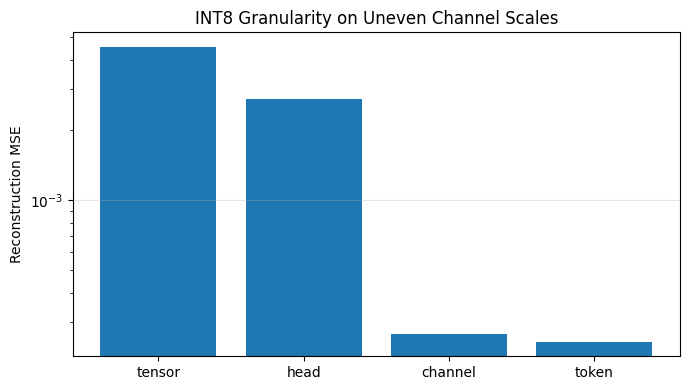

In [4]:
torch.manual_seed(1)
X = torch.randn(1, 2, 65, 32, device=device)
X = X * torch.linspace(0.1, 4.0, 32, device=device)
X[0, 0, 0, 0] = 30.0
granularity_rows = []
for granularity in ("tensor", "head", "channel", "token"):
    params = calibrate_qparams(X, reduce_dims=reduction_dims(granularity))
    packed = quantize_tensor(X, params)
    row = dict(experiment="granularity", granularity=granularity, bits=8,
               scale_shape=list(params.scale.shape), scale_count=params.scale.numel(),
               encoded_storage_bytes=packed.storage_bytes(), device=device,
               **error_metrics(packed.dequantize(), X))
    granularity_rows.append(row)
    error_records.append(row)
print(pd.DataFrame(granularity_rows)[["granularity", "scale_shape", "scale_count", "mse"]]
      .to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([r["granularity"] for r in granularity_rows], [r["mse"] for r in granularity_rows])
ax.set(yscale="log", ylabel="Reconstruction MSE", title="INT8 Granularity on Uneven Channel Scales")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "04_granularity.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.2 静态校准与动态量化（考虑Calibration）

PTQ 不更新模型参数。权重固定，可以提前求量化参数；激活取决于输入，有两种常见做法：

- **静态量化**：用有代表性的校准数据求参数，推理时固定使用。
- **动态量化**：推理时根据当前激活求参数，额外付出范围统计的开销。

静态校准应覆盖实际输入的长度、尺度和常见异常值，评估数据要与校准数据分开。这里只用独立的合成数据说明问题：把校准数据的范围用于尺度更大的评估数据，会增加截断。实际模型还应测任务准确率或困惑度。

min/max 校准能覆盖观测极值，但异常值会扩大步长。按百分位截断可以降低多数值的舍入误差，同时引入截断误差；是否合适，应在独立验证数据上选择。本例同时打印舍入后编码被截断的比例与 MSE，再比较这组数据上的结果。编码是否需要截断由舍入后的整数判断，不等于直接统计浮点值是否超过观测范围。

In [5]:
torch.manual_seed(2)
calibration = torch.randn(4096, device=device)
evaluation = 2.5 * torch.randn(4096, device=device)
evaluation[::257] *= 8

static_params = calibrate_qparams(calibration)
dynamic_params = calibrate_qparams(evaluation)
# 用全局百分位截断；没有用评估数据选百分位。
clip_bound = torch.quantile(calibration.abs(), 0.999)
clipped_params = calibrate_qparams(calibration.clamp(-clip_bound, clip_bound))

calibration_rows = []
for name, params in [("static_minmax", static_params),
                     ("static_percentile", clipped_params), ("dynamic_minmax", dynamic_params)]:
    unbounded_codes = torch.round(evaluation / params.scale) + params.zero_point
    clipping_fraction = ((unbounded_codes < params.qmin) |
                         (unbounded_codes > params.qmax)).float().mean().item()
    restored = quantize_tensor(evaluation, params).dequantize()
    row = dict(experiment="calibration_shift", impl=name, bits=8,
               clipping_fraction=clipping_fraction, device=device,
               **error_metrics(restored, evaluation))
    calibration_rows.append(row)
    error_records.append(row)
print(pd.DataFrame(calibration_rows)[["impl", "clipping_fraction", "mse"]].to_string(index=False))

             impl  clipping_fraction      mse
    static_minmax           0.164307 1.561297
static_percentile           0.184814 1.658405
   dynamic_minmax           0.000000 0.010644


## 4 PyTorch 的 CPU 动态量化

`torch.quantization` 是较早的入口，本例使用 `torch.ao.quantization.quantize_dynamic`。PyTorch 已将后续量化开发迁移到 `torchao`，并将这个旧接口标记为弃用；这里保留它，便于在已有 PyTorch 环境中直接观察 INT8 Linear。新项目应按版本核对 `torchao` 的配置和设备支持。[PyTorch 量化文档](https://docs.pytorch.org/docs/2.11/quantization.html)

以下小型 MHA 沿用 01 的计算流程，但用 SDPA 完成注意力核心：投影得到 $Q,K,V$，按头计算注意力，拼接后做输出投影。动态量化只替换四个 `nn.Linear`：权重提前转为 INT8，运行时量化线性层输入，输出仍是浮点。它不需要单独的激活校准集，也没有把 SDPA 替换为整数注意力。[动态量化接口](https://docs.pytorch.org/docs/2.11/generated/torch.ao.quantization.quantize_dynamic.html)

CPU 实验单独运行，不把 CPU INT8 与 GPU FP32 的延迟做加速比。没有可用量化 engine 时明确跳过；实际执行错误直接抛出。

In [6]:
class SmallMHA(nn.Module):
    def __init__(self, d_model=128, h=4):
        super().__init__()
        if d_model % h != 0:
            raise ValueError("d_model 必须能被 h 整除")
        self.h = h
        self.d_k = d_model // h
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def project(self, X):
        B, N, _ = X.shape
        def split(Y):
            return Y.reshape(B, N, self.h, self.d_k).transpose(1, 2)
        return split(self.W_Q(X)), split(self.W_K(X)), split(self.W_V(X))

    def forward(self, X, causal=False):
        Q, K, V = self.project(X)
        O = F.scaled_dot_product_attention(Q, K, V, is_causal=causal, dropout_p=0.0)
        O = O.transpose(1, 2).contiguous().reshape_as(X)
        return self.W_O(O)

torch.manual_seed(3)
mha_fp32 = SmallMHA().cpu().eval()
mha_int8 = None
supported_engines = [e for e in torch.backends.quantized.supported_engines if e != "none"]
if supported_engines:
    if torch.backends.quantized.engine not in supported_engines:
        torch.backends.quantized.engine = supported_engines[0]
    from torch.ao.quantization import quantize_dynamic
    # 只捕获并简短展示旧接口的弃用提示，其他警告照常展示。
    with warnings.catch_warnings(record=True) as captured:
        warnings.filterwarnings("always", category=DeprecationWarning)
        mha_int8 = quantize_dynamic(copy.deepcopy(mha_fp32), {nn.Linear}, dtype=torch.qint8)
    deprecation_shown = False
    for warning in captured:
        if warning.category is DeprecationWarning and "torch.ao.quantization" in str(warning.message):
            if not deprecation_shown:
                print("提示: 当前 PyTorch 将 torch.ao.quantization 标记为弃用，新项目请核对 torchao。")
                deprecation_shown = True
        else:
            warnings.warn(str(warning.message), warning.category)
    print(mha_int8.W_Q)
    assert mha_int8.W_Q.weight().dtype == torch.qint8
    X_cpu = torch.randn(1, 65, 128)
    with torch.no_grad():
        for causal in (False, True):
            reference = mha_fp32(X_cpu, causal)
            output = mha_int8(X_cpu, causal)
            assert output.shape == reference.shape and torch.isfinite(output).all()
            metrics = error_metrics(output, reference)
            print(f"causal={causal}, MSE={metrics['mse']:.2e}, cosine={metrics['cosine_similarity']:.6f}")
            error_records.append(dict(experiment="dynamic_int8_mha", causal=causal,
                                      device="cpu", seq_len=65, d_model=128, **metrics))
    tool_records.append(dict(tool="torch.ao.quantization", status="ok", device="cpu",
                             engine=torch.backends.quantized.engine))
else:
    reason = "当前 PyTorch 没有可用的 CPU 量化 engine"
    print("跳过动态 INT8:", reason)
    tool_records.append(dict(tool="torch.ao.quantization", status="unsupported", reason=reason))

提示: 当前 PyTorch 将 torch.ao.quantization 标记为弃用，新项目请核对 torchao。
DynamicQuantizedLinear(in_features=128, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
causal=False, MSE=1.47e-06, cosine=0.999593
causal=True, MSE=1.62e-05, cosine=0.999165


## 5 量化误差分析

对输出 $\hat O$ 与同一输入的 FP32 参考 $O$，统计：

$$
\operatorname{MSE}=\frac{\|\hat O-O\|_F^2}{BhNd_k},\qquad
\operatorname{RelativeL2}=\frac{\|\hat O-O\|_F}{\|O\|_F},\qquad
\operatorname{Cosine}=\frac{\langle\hat O,O\rangle}{\|\hat O\|_F\|O\|_F}.
$$

余弦相似度主要反映方向，无法单独判断幅值是否准确；MSE 又随数据尺度变化，因此一起查看，并补充最大绝对误差。参考输出范数为 0 时，相对 L2 误差记为 `null`；任一输出范数为 0 时，余弦相似度记为 `null`。

下面比较 4/6/8-bit、三种粒度、普通及因果注意力。每个设置使用同一组输入，参考实现与量化模拟使用相同的 FP32 运算顺序，以减少 backend 差异。另加入单个 $K$ 异常值，观察误差变化。这里只量化 $Q,K,V$，不量化 $A$。

distribution granularity      mse  relative_l2  cosine_similarity
      normal      tensor 0.000007     0.013680           0.999906
      normal     channel 0.000004     0.010013           0.999950
      normal       token 0.000003     0.009291           0.999957
     outlier      tensor 0.000148     0.039703           0.999212
     outlier     channel 0.000009     0.009658           0.999955
     outlier       token 0.000030     0.017735           0.999843


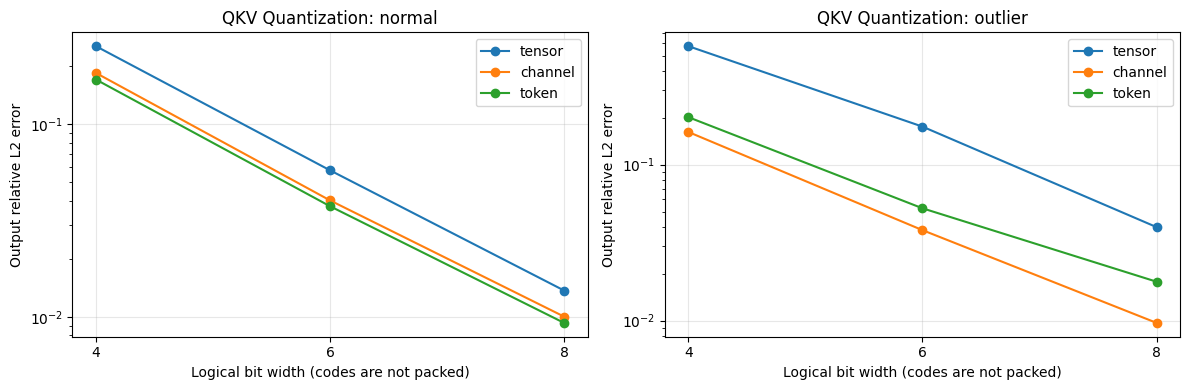

In [7]:
torch.manual_seed(5)
Q_eval = torch.randn(1, 2, 65, 32, device=device)
K_eval = torch.randn_like(Q_eval)
V_eval = torch.randn_like(Q_eval)
sweep_rows = []
with torch.no_grad():
    for distribution in ("normal", "outlier"):
        K_case = K_eval.clone()
        if distribution == "outlier":
            K_case[0, 0, 0, 0] = 30.0
        for causal in (False, True):
            reference, _ = attention_fp32(Q_eval, K_case, V_eval, causal)
            for bits in (4, 6, 8):
                for granularity in ("tensor", "channel", "token"):
                    output = qdq_attention(Q_eval, K_case, V_eval, bits=bits,
                                           granularity=granularity, causal=causal)
                    row = dict(experiment="bitwidth_sweep", distribution=distribution,
                               bits=bits, granularity=granularity, causal=causal, seq_len=65,
                               d_k=32, device=device, **error_metrics(output, reference))
                    sweep_rows.append(row)
                    error_records.append(row)
sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df[(sweep_df["bits"] == 8) & ~sweep_df["causal"]]
      [["distribution", "granularity", "mse", "relative_l2", "cosine_similarity"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, distribution in zip(axes, ("normal", "outlier")):
    for granularity in ("tensor", "channel", "token"):
        rows = sweep_df[(sweep_df["distribution"] == distribution) &
                        (sweep_df["granularity"] == granularity) & ~sweep_df["causal"]]
        ax.plot(rows["bits"], rows["relative_l2"], marker="o", label=granularity)
    ax.set(xlabel="Logical bit width (codes are not packed)", ylabel="Output relative L2 error",
           yscale="log", title=f"QKV Quantization: {distribution}", xticks=[4, 6, 8])
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "04_quantization_error.png", dpi=120, bbox_inches="tight")
plt.show()

低位宽会增大步长，但具体误差还受粒度、异常值和注意力分布影响。以上曲线没有包含训练好的模型，也没有把校准分布变化混进位宽实验。

部署前应把同样的测量放到真实模型和独立数据集上：先检查投影与每层注意力的误差，再检查最终任务指标。单个随机张量上余弦接近 1，不能证明模型质量没有下降。

## 6 量化感知怎么训练

PTQ 在训练完成后选择量化参数；QAT 在训练中模拟舍入和截断，让浮点参数适应量化误差。前向仍可用浮点张量保存 $\hat x$，因此 QAT 的训练显存不等于 INT8 推理显存。

`round` 几乎处处的导数为 0。Straight-Through Estimator（STE）在反向中用近似导数传递梯度。这里采用常见的截断版：舍入编码仍在允许范围内时传递梯度，超出范围时设为 0。

$$
\frac{\partial\hat x}{\partial x}\approx
\begin{cases}
1,&q_{\min}\le\operatorname{round}(x/s)\le q_{\max},\\
0,&\text{其他情况}.
\end{cases}
$$

这是用于训练的近似，不是量化函数的真实导数。下面固定一个正的 scale，并令 zero-point 为 0，与 PyTorch 的 fake-quantize 核对前向值和梯度，然后训练一个小线性层。[STE 原始论文](https://arxiv.org/abs/1308.3432)、[PyTorch fake-quantize](https://docs.pytorch.org/docs/2.11/generated/torch.fake_quantize_per_tensor_affine.html)

In [8]:
class SymmetricFakeQuantSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale, qmax):
        q = torch.round(x / scale)
        ctx.save_for_backward((q >= -qmax) & (q <= qmax))
        return q.clamp(-qmax, qmax) * scale

    @staticmethod
    def backward(ctx, grad_output):
        (inside,) = ctx.saved_tensors
        return grad_output * inside, None, None

def fake_quant_ste(x, scale, bits=8):
    return SymmetricFakeQuantSTE.apply(x, scale, 2 ** (bits - 1) - 1)

x_ste = torch.tensor([-2.0, -0.6, -0.12, 0.0, 0.12, 0.6, 2.0], requires_grad=True)
y_ste = fake_quant_ste(x_ste, scale=0.1, bits=4)
y_ste.sum().backward()
x_builtin = x_ste.detach().clone().requires_grad_()
y_builtin = torch.fake_quantize_per_tensor_affine(x_builtin, 0.1, 0, -7, 7)
y_builtin.sum().backward()
torch.testing.assert_close(y_ste, y_builtin)
torch.testing.assert_close(x_ste.grad, x_builtin.grad)
print("前向:", y_ste.detach().tolist())
print("STE 梯度:", x_ste.grad.tolist())

前向: [-0.699999988079071, -0.6000000238418579, -0.10000000149011612, 0.0, 0.10000000149011612, 0.6000000238418579, 0.699999988079071]
STE 梯度: [0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0]


示例训练 MSE: 9.63e-02 -> 1.08e-04


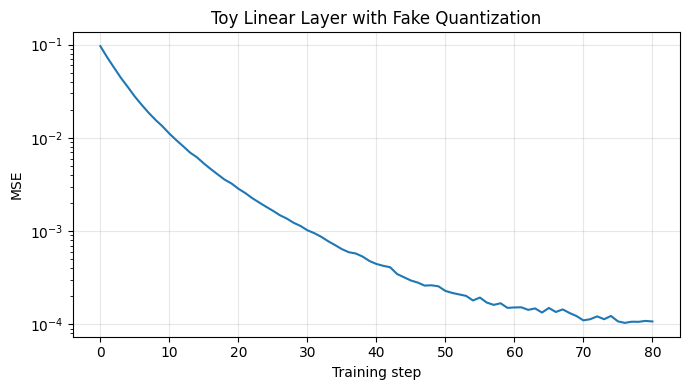

In [9]:
# CPU 上的小实验，只说明带量化误差的前向仍能训练，不代表完整 MHA 的 QAT。
torch.manual_seed(6)
X_train = torch.randn(64, 16)
W_teacher = torch.randn(8, 16) * 0.15
target = F.linear(X_train, W_teacher)
W_student = nn.Parameter(W_teacher + 0.08 * torch.randn_like(W_teacher))
optimizer = torch.optim.SGD([W_student], lr=0.4)
scale_x, scale_w = 0.04, 0.005  # 固定参数，便于看清 STE 的作用。
loss_history = []
for step in range(81):
    prediction = F.linear(fake_quant_ste(X_train, scale_x), fake_quant_ste(W_student, scale_w))
    loss = F.mse_loss(prediction, target)
    loss_history.append(loss.item())
    if step < 80:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
assert torch.isfinite(W_student).all()
assert loss_history[-1] < loss_history[0]
print(f"示例训练 MSE: {loss_history[0]:.2e} -> {loss_history[-1]:.2e}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loss_history)
ax.set(xlabel="Training step", ylabel="MSE", yscale="log", title="Toy Linear Layer with Fake Quantization")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "04_qat_demo.png", dpi=120, bbox_inches="tight")
plt.show()
save_json("04_qat_demo.json", dict(scope="toy_linear_ste", device="cpu", loss=loss_history,
                                  scale_x=scale_x, scale_w=scale_w, bits=8))

完整 QAT 还要加入统计输入范围的模块（observer）和模拟量化的模块（fake-quantize），选择哪些值共用参数，再决定何时停止更新这些统计量，最后转换为目标 backend 支持的算子。上面的 STE 只展示训练原理，没有自动完成这些步骤，也没有训练真实 Transformer。

## 7 基准测试

### 7.1 测量口径

下面分别测两个范围，结果用 `scope` 区分：

- `attention_core`：同样的 FP32 $Q,K,V$，比较手写 FP32 注意力、自动 SDPA，以及 INT8 编码后反量化再运行手写注意力。后者的计时包含范围统计、编码和反量化，矩阵乘仍是 FP32。
- `mha_layer` / `qkv_projection`：同样的 CPU FP32 输入 $X$ 和权重，比较 FP32 与真实动态 INT8 投影。完整 MHA 包含四个投影及浮点 SDPA；投影单测包含前三个 Linear、拆头与堆叠输出，不含 SDPA 和输出投影。

计时关闭梯度和 dropout，预热后使用 `torch.utils.benchmark` 测 20 次调用的平均延迟，CPU 使用 1 个线程。CUDA 上记录**调用新增的峰值已分配显存**，包含输出和临时张量，减去已经存在的输入和模型；CPU 的显存记为 `null`，没有把它当作 CPU RAM。

模型权重数据量与调用峰值分开统计。只有相同设备、输入、计算范围、掩码和测量口径的结果才适合做加速比。自动 SDPA 单独标为 auto，其名字不代表选用了 Flash backend。

In [10]:
@torch.no_grad()
def measure_latency_memory(fn, *args):
    dev = args[0].device
    for _ in range(3):
        fn(*args)
    if dev.type == "cuda":
        torch.cuda.synchronize(dev)
        baseline = torch.cuda.memory_allocated(dev)
        torch.cuda.reset_peak_memory_stats(dev)
        output = fn(*args)
        torch.cuda.synchronize(dev)
        memory_mb = (torch.cuda.max_memory_allocated(dev) - baseline) / 1e6
        del output
    else:
        memory_mb = None
    timing = benchmark.Timer(stmt="fn(*args)", globals={"fn": fn, "args": args},
                             num_threads=1).timeit(20)
    return dict(latency_ms=timing.mean * 1e3, timing_iterations=20,
                cpu_num_threads=1, memory_mb=memory_mb,
                memory_metric="incremental_peak_allocated", device=str(dev),
                input_dtype=str(args[0].dtype), torch_version=torch.__version__, status="ok")

def fp32_core(Q, K, V):
    return attention_fp32(Q, K, V)[0]

def auto_sdpa_core(Q, K, V):
    return F.scaled_dot_product_attention(Q, K, V, dropout_p=0.0)

def qdq_core(Q, K, V):
    return qdq_attention(Q, K, V, bits=8, granularity="token")

benchmark_records = []
bench_seq_lens = [64, 128, 256, 512]
core_methods = [("fp32_explicit", fp32_core), ("sdpa_auto_fp32", auto_sdpa_core),
                ("int8_qdq_fp32_compute", qdq_core)]
for N in bench_seq_lens:
    torch.manual_seed(7)
    Q_bench = torch.randn(1, 2, N, 32, device=device)
    K_bench = torch.randn_like(Q_bench)
    V_bench = torch.randn_like(Q_bench)
    with torch.no_grad():
        reference = fp32_core(Q_bench, K_bench, V_bench)
    for name, fn in core_methods:
        metadata = dict(impl=name, scope="attention_core", seq_len=N, batch=1, heads=2,
                        d_k=32, causal=False, dropout_p=0.0,
                        compute="fp32", quantization="qdq_int8" if fn is qdq_core else "none")
        try:
            row = dict(**metadata, **measure_latency_memory(fn, Q_bench, K_bench, V_bench))
            with torch.no_grad():
                output = fn(Q_bench, K_bench, V_bench)
                row.update(error_metrics(output, reference))
                del output
        except torch.cuda.OutOfMemoryError:
            row = dict(**metadata, status="oom", latency_ms=None, memory_mb=None, device=device)
            torch.cuda.empty_cache()
        benchmark_records.append(row)
        print(f"N={N:4d}, {name:25s}: " +
              (f"{row['latency_ms']:.3f} ms" if row["status"] == "ok" else row["status"]))
    del Q_bench, K_bench, V_bench, reference

N=  64, fp32_explicit            : 0.313 ms
N=  64, sdpa_auto_fp32           : 0.125 ms
N=  64, int8_qdq_fp32_compute    : 4.491 ms


N= 128, fp32_explicit            : 0.179 ms
N= 128, sdpa_auto_fp32           : 0.105 ms
N= 128, int8_qdq_fp32_compute    : 2.551 ms
N= 256, fp32_explicit            : 0.166 ms
N= 256, sdpa_auto_fp32           : 0.134 ms


N= 256, int8_qdq_fp32_compute    : 2.763 ms
N= 512, fp32_explicit            : 0.299 ms
N= 512, sdpa_auto_fp32           : 0.261 ms
N= 512, int8_qdq_fp32_compute    : 2.700 ms


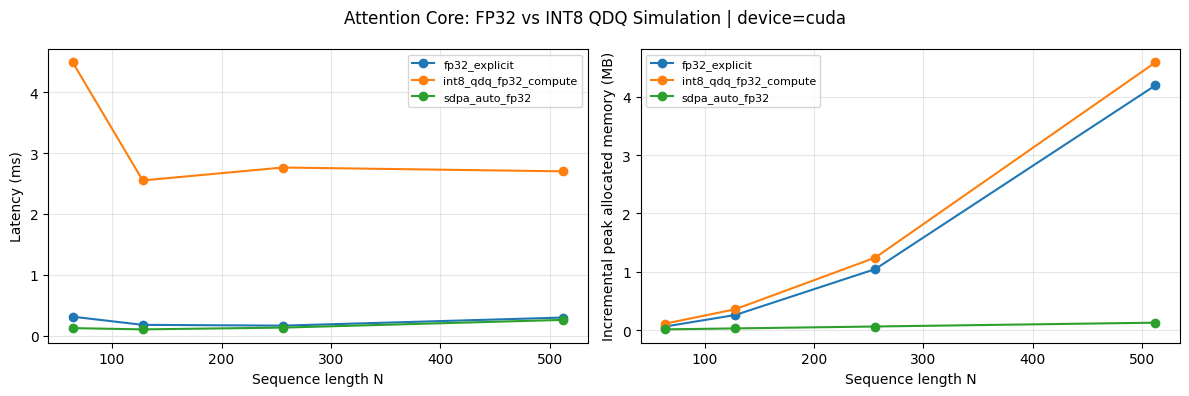

In [11]:
def plot_benchmark(rows, filename, title):
    frame = pd.DataFrame([r for r in rows if r["status"] == "ok"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, ylabel in zip(axes, ("latency_ms", "memory_mb"),
                                 ("Latency (ms)", "Incremental peak allocated memory (MB)")):
        if not frame.empty:
            for impl, group in frame.groupby("impl"):
                group = group.sort_values("seq_len")
                valid = group.dropna(subset=[metric])
                if not valid.empty:
                    ax.plot(valid["seq_len"], valid[metric], marker="o", label=impl)
        ax.set(xlabel="Sequence length N", ylabel=ylabel)
        ax.grid(alpha=0.3)
        if ax.lines:
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, "CUDA memory not measured on CPU", transform=ax.transAxes,
                    ha="center", fontsize=9)
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(results_dir / filename, dpi=120, bbox_inches="tight")
    plt.show()

plot_benchmark(benchmark_records, "04_benchmark_plot.png",
               f"Attention Core: FP32 vs INT8 QDQ Simulation | device={device}")

### 7.2 真实 INT8 投影与完整 MHA

这部分始终在 CPU 运行。量化转换和权重打包在计时前完成，推理中的激活量化包含在延迟中。完整 MHA 的主要计算仍包含浮点注意力，长序列时它可能掩盖投影层的变化，因此另测 $Q,K,V$ 三个投影。

下面的权重数据量从四个 Linear 的权重读取。INT8 情况计入每张量或每通道的 scale/zero-point，排除 backend 的打包、对齐和对象开销；这是可解释的数据量，不能代替进程实际 RAM 峰值。

         scope  seq_len         impl  latency_ms  relative_l2
qkv_projection       64         fp32    0.311333     0.000000
qkv_projection       64 dynamic_int8    0.288886     0.017583
     mha_layer       64         fp32    0.448171     0.000000
     mha_layer       64 dynamic_int8    0.467210     0.020813
qkv_projection      128         fp32    0.649700     0.000000
qkv_projection      128 dynamic_int8    0.468641     0.017735
     mha_layer      128         fp32    0.757050     0.000000
     mha_layer      128 dynamic_int8    0.780559     0.021667
qkv_projection      256         fp32    0.636167     0.000000
qkv_projection      256 dynamic_int8    0.576808     0.019991
     mha_layer      256         fp32    1.518758     0.000000
     mha_layer      256 dynamic_int8    1.384016     0.029825
qkv_projection      512         fp32    1.128389     0.000000
qkv_projection      512 dynamic_int8    0.591050     0.020681
     mha_layer      512         fp32    4.448341     0.000000
     mha

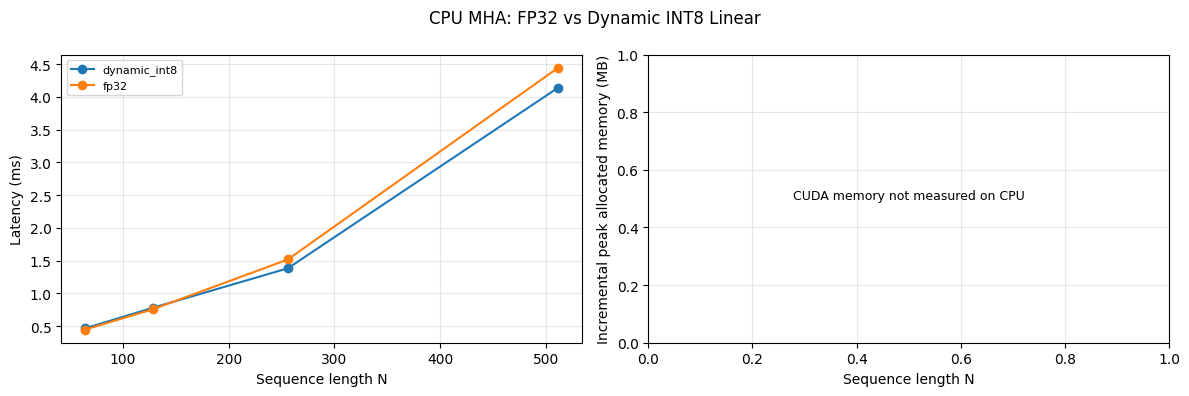

In [12]:
def linear_weight_storage_bytes(model):
    total = 0
    for name in ("W_Q", "W_K", "W_V", "W_O"):
        layer = getattr(model, name)
        weight = layer.weight() if callable(layer.weight) else layer.weight
        total += weight.numel() * weight.element_size()
        if weight.is_quantized:
            if weight.qscheme() in (torch.per_channel_affine, torch.per_channel_symmetric):
                scales, zeros = weight.q_per_channel_scales(), weight.q_per_channel_zero_points()
                total += scales.numel() * scales.element_size() + zeros.numel() * zeros.element_size()
            else:
                total += 16  # q_scale() 的 double 与 q_zero_point() 的 int64 数据量。
    return total

weight_records = []
cpu_rows = []
for name, model in [("mha_fp32", mha_fp32), ("mha_dynamic_int8", mha_int8)]:
    if model is not None:
        weight_records.append(dict(impl=name, device="cpu", d_model=128,
                                   weight_storage_bytes=linear_weight_storage_bytes(model),
                                   storage_metric="weight_data_and_qparams_excluding_packing"))

for N in bench_seq_lens:
    torch.manual_seed(8)
    X_bench = torch.randn(1, N, 128)
    for scope in ("qkv_projection", "mha_layer"):
        # 投影返回一个拼接后的张量，便于使用同一套输出误差统计。
        def run_model(model, X):
            if scope == "mha_layer":
                return model(X)
            return torch.stack(model.project(X), dim=0)
        with torch.no_grad():
            reference = run_model(mha_fp32, X_bench)
        for name, model in [("fp32", mha_fp32), ("dynamic_int8", mha_int8)]:
            metadata = dict(impl=name, scope=scope, seq_len=N, batch=1, heads=4,
                            d_k=32, d_model=128, causal=False, dropout_p=0.0,
                            compute=("int8_linear_float_sdpa" if scope == "mha_layer" else "int8_linear")
                            if name == "dynamic_int8" else "fp32",
                            quantization="dynamic_int8" if name == "dynamic_int8" else "none",
                            quantized_engine=torch.backends.quantized.engine if model is mha_int8 else None)
            if model is None:
                row = dict(**metadata, device="cpu", status="unsupported", latency_ms=None,
                           memory_mb=None, reason="没有可用的 CPU 量化 engine")
            else:
                fn = lambda X, model=model: run_model(model, X)
                row = dict(**metadata, **measure_latency_memory(fn, X_bench))
                with torch.no_grad():
                    row.update(error_metrics(fn(X_bench), reference))
                # 这里计入当前范围涉及的权重，不把 W_O 算进 QKV 投影。
                total_weights = linear_weight_storage_bytes(model)
                row["weight_storage_bytes"] = total_weights if scope == "mha_layer" else total_weights * 3 // 4
            cpu_rows.append(row)
            benchmark_records.append(row)
    del X_bench, reference

cpu_df = pd.DataFrame([r for r in cpu_rows if r["status"] == "ok"])
print(cpu_df[["scope", "seq_len", "impl", "latency_ms", "relative_l2"]].to_string(index=False))
print("权重数据量:", weight_records)
if mha_int8 is not None:
    latency_table = cpu_df.pivot(index=["scope", "seq_len"], columns="impl", values="latency_ms")
    latency_table["speedup_fp32_over_int8"] = latency_table["fp32"] / latency_table["dynamic_int8"]
    print("实测加速比（>1 表示 INT8 更快）:")
    print(latency_table[["speedup_fp32_over_int8"]].to_string())
plot_benchmark([r for r in cpu_rows if r["scope"] == "mha_layer"],
               "04_mha_cpu_benchmark.png", "CPU MHA: FP32 vs Dynamic INT8 Linear")

### 7.3 存储压缩不等于峰值显存下降

逐 token 对称 INT8 的 $Q,K,V$ 共 $3BhNd_k$ 个编码。本例每组参数保存一个 FP32 scale 和一个 INT32 zero-point，因此编码数据量为

$$
3BhNd_k + 3BhN(4+4)\quad\text{bytes}.
$$

对称量化的零点固定为 0，实际 kernel 可以省去这部分元数据。本节为了通用数据结构仍保留它。下面只算已编码张量的数据量，与 FP32/FP16 的 $Q,K,V$ 数据量比较；不是 allocator 的显存实测。

前面的 QDQ 模拟还保留原始输入，并生成反量化 FP32 张量和完整 $S,A$，所以编码存储更小也不保证调用峰值更小。即使把显式 $A$ 从 32 位降到 8 位，它的元素数仍为 $BhN^2$。FlashAttention 避免完整 $A$，量化减少位宽，两者作用不同；结合使用需要支持相应格式的融合 kernel。

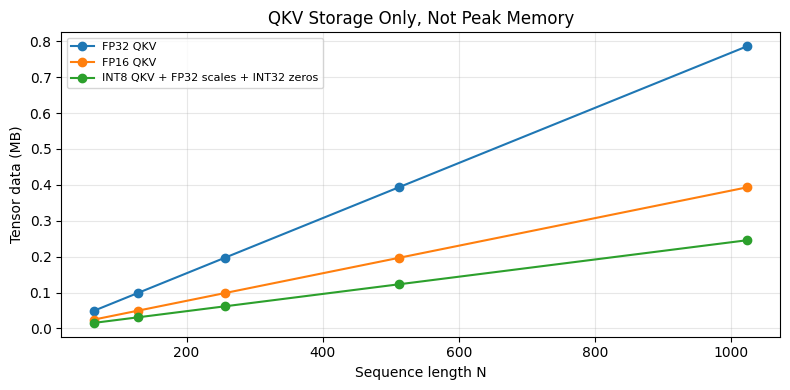

In [13]:
storage_rows = []
for N in (64, 128, 256, 512, 1024):
    shape = (1, 2, N, 32)
    elements = math.prod(shape)
    x = torch.zeros(shape)  # CPU 上实际构造编码，包含 scale 与 zero-point。
    packed = quantize_tensor(x, calibrate_qparams(x, reduce_dims=(3,)))
    storage_rows.append(dict(seq_len=N, batch=1, heads=2, d_k=32,
                             qkv_fp32_bytes=3 * elements * 4,
                             qkv_fp16_bytes=3 * elements * 2,
                             qkv_int8_with_params_bytes=3 * packed.storage_bytes(),
                             metric="tensor_data_bytes_excluding_allocator"))
fig, ax = plt.subplots(figsize=(8, 4))
for key, label in [("qkv_fp32_bytes", "FP32 QKV"), ("qkv_fp16_bytes", "FP16 QKV"),
                   ("qkv_int8_with_params_bytes", "INT8 QKV + FP32 scales + INT32 zeros")]:
    ax.plot([r["seq_len"] for r in storage_rows], [r[key] / 1e6 for r in storage_rows],
            marker="o", label=label)
ax.set(xlabel="Sequence length N", ylabel="Tensor data (MB)", title="QKV Storage Only, Not Peak Memory")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_dir / "04_storage.png", dpi=120, bbox_inches="tight")
plt.show()

### 7.4 精度与延迟的 Pareto 前沿

在同一个设置下，如果另一方法延迟不更高、误差不更大，并至少有一项更好，当前方法就被它支配。没有被支配的方法构成 Pareto 前沿。

下面固定 $N=256$，分别查看注意力核心、CPU 投影和 CPU MHA；不跨组比较。误差使用相对 L2，而不是把不同尺度的 MSE 混合。模拟量化如果误差更大、延迟也更高，就不会进入前沿，这是测量结果的一种正常情况。

小误差本身可能包含浮点舍入，短时间计时也有波动。前沿只针对本机的这些测点，不是对所有设备和真实模型的结论。若目标是内存约束，还应把模型常驻内存和调用峰值作为额外条件。

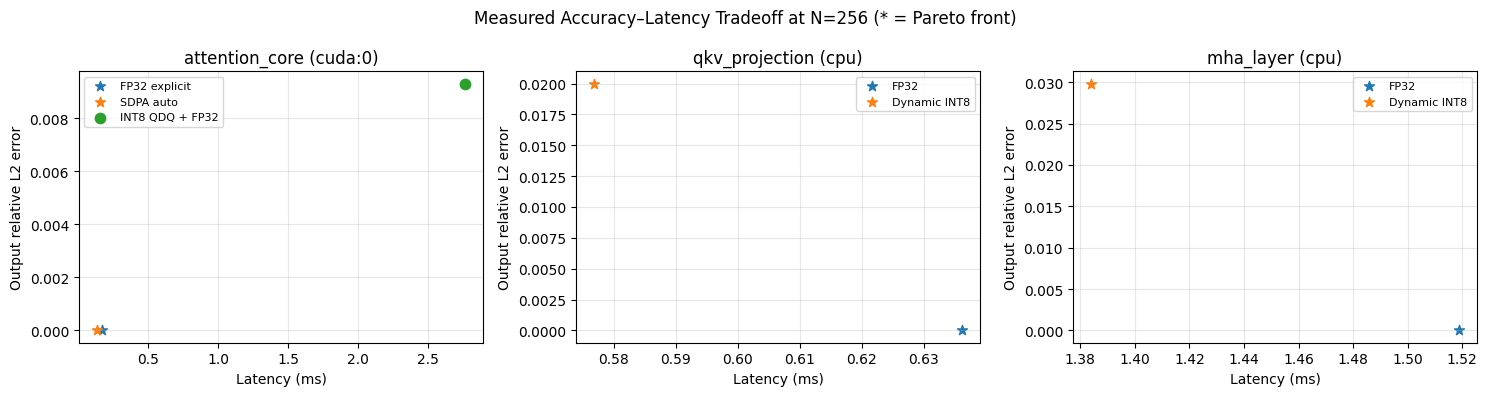

04 的误差、存储、工具链和性能结果已保存至 /mnt/e/Programming/efficient-attention-lab-wsl-submission-20261004-134359/project/results


In [14]:
def pareto_front(rows):
    valid = [r for r in rows if r["status"] == "ok" and r.get("relative_l2") is not None]
    return [r for r in valid if not any(
        other["latency_ms"] <= r["latency_ms"] and other["relative_l2"] <= r["relative_l2"]
        and (other["latency_ms"] < r["latency_ms"] or other["relative_l2"] < r["relative_l2"])
        for other in valid
    )]

pareto_records = []
display_names = {"fp32_explicit": "FP32 explicit", "sdpa_auto_fp32": "SDPA auto",
                 "int8_qdq_fp32_compute": "INT8 QDQ + FP32", "fp32": "FP32",
                 "dynamic_int8": "Dynamic INT8"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, scope in zip(axes, ("attention_core", "qkv_projection", "mha_layer")):
    rows = [r for r in benchmark_records if r["scope"] == scope and r["seq_len"] == 256
            and r["status"] == "ok"]
    front = pareto_front(rows)
    front_names = {r["impl"] for r in front}
    for row in rows:
        ax.scatter(row["latency_ms"], row["relative_l2"], s=55,
                   marker="*" if row["impl"] in front_names else "o",
                   label=display_names[row["impl"]])
        pareto_records.append(dict(scope=scope, seq_len=256, device=row["device"], impl=row["impl"],
                                   latency_ms=row["latency_ms"], relative_l2=row["relative_l2"],
                                   on_front=row["impl"] in front_names))
    group_device = rows[0]["device"] if rows else "no data"
    ax.set(xlabel="Latency (ms)", ylabel="Output relative L2 error", title=f"{scope} ({group_device})")
    if rows:
        ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle("Measured Accuracy–Latency Tradeoff at N=256 (* = Pareto front)")
plt.tight_layout()
plt.savefig(results_dir / "04_pareto.png", dpi=120, bbox_inches="tight")
plt.show()

save_json("04_benchmark_quantization.json", benchmark_records)
save_json("04_quantization_error.json", error_records)
save_json("04_quantization_storage.json", dict(qkv=storage_rows, weights=weight_records))
save_json("04_quantization_tools.json", tool_records)
save_json("04_pareto.json", pareto_records)
save_json("04_environment.json", dict(torch_version=torch.__version__, numpy_version=np.__version__,
                                      device=device, cuda_version=torch.version.cuda,
                                      gpu=torch.cuda.get_device_name(0) if device == "cuda" else None,
                                      quantized_engine=torch.backends.quantized.engine,
                                      float32_matmul_precision=torch.get_float32_matmul_precision()))
print("04 的误差、存储、工具链和性能结果已保存至", results_dir)

## 8 小结

本节主要学习了 INT8 量化的基本原理，并通过实验比较了量化前后的输出误差和运行时间。量化可以用更少的位数表示数据，从而减少存储空间，但也会带来一定误差。对于注意力计算，Q、K、V 和注意力权重的变化都可能影响最终输出，因此需要结合实验结果判断量化方案是否合适。

在量化方案的选择上，需要同时考虑误差、存储和运行速度。针对不同通道或 token 分别设置量化参数，可以更好地适应数据的差异，但也会增加处理开销。本节还介绍了训练后量化和量化感知训练：前者不需要重新训练模型，后者则在训练过程中模拟量化，让模型逐渐适应误差。另外，使用 INT8 并不一定会加快运行速度，还要看设备和计算工具是否支持，以及数据转换需要多少时间。

通过本节的学习，可以看出量化和 FlashAttention 都是在提高计算效率，但思路有所不同：量化主要减少数据的存储位数，FlashAttention 主要减少中间数据的读写。本节使用的是合成数据和小型示例，结果还不能直接代表真实模型的表现。后续可以在实际模型和数据集上继续实验，比较任务效果、运行时间和内存占用，再判断采用 INT8 是否合适。实验结果已保存到 results 目录，方便后续分析。

**参考文献**

- [PyTorch 量化与迁移说明](https://docs.pytorch.org/docs/2.11/quantization.html)
- [PyTorch 动态量化接口](https://docs.pytorch.org/docs/2.11/generated/torch.ao.quantization.quantize_dynamic.html)
- [PyTorch fake-quantize 接口](https://docs.pytorch.org/docs/2.11/generated/torch.fake_quantize_per_tensor_affine.html)
- [FP8 Formats for Deep Learning，2022](https://arxiv.org/abs/2209.05433)
- [Straight-Through Estimator，2013](https://arxiv.org/abs/1308.3432)
- [FlashAttention，本地 PDF](https://arxiv.org/abs/2205.14135)